In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_dog, graycomatrix, local_binary_pattern

# Configure matplotlib for professional, high-res output
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

# --- INPUT ---
# Replace with the path to your actual .tif image
IMAGE_PATH = 'sample_patch.tif' 

# Load image
img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise ValueError(f"Could not load image at {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Image loaded successfully. Shape: {img_rgb.shape}")

Image loaded successfully. Shape: (96, 96, 3)


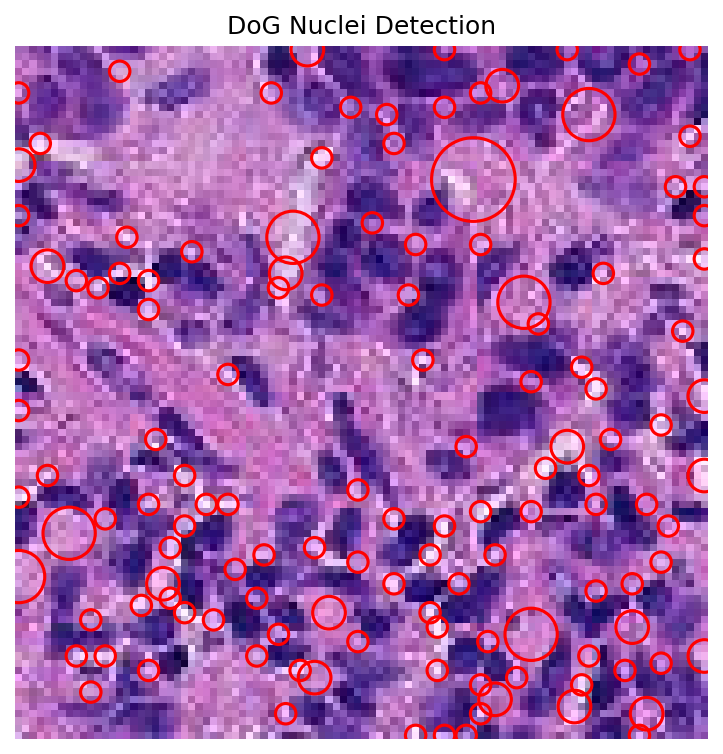

In [2]:
# Detect blobs using Difference of Gaussians
# (Parameters can be tuned based on your specific patch scale)
blobs = blob_dog(img_gray, max_sigma=5, threshold=0.1)
blobs[:, 2] = blobs[:, 2] * np.sqrt(2) # Calculate radius

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img_rgb)

# Plot each detected blob
for blob in blobs:
    y, x, r = blob
    c = plt.Circle((x, y), r, color='red', linewidth=1.5, fill=False)
    ax.add_patch(c)

ax.set_title('DoG Nuclei Detection')
ax.axis('off')

plt.savefig('dog_visualization.png')
plt.show()

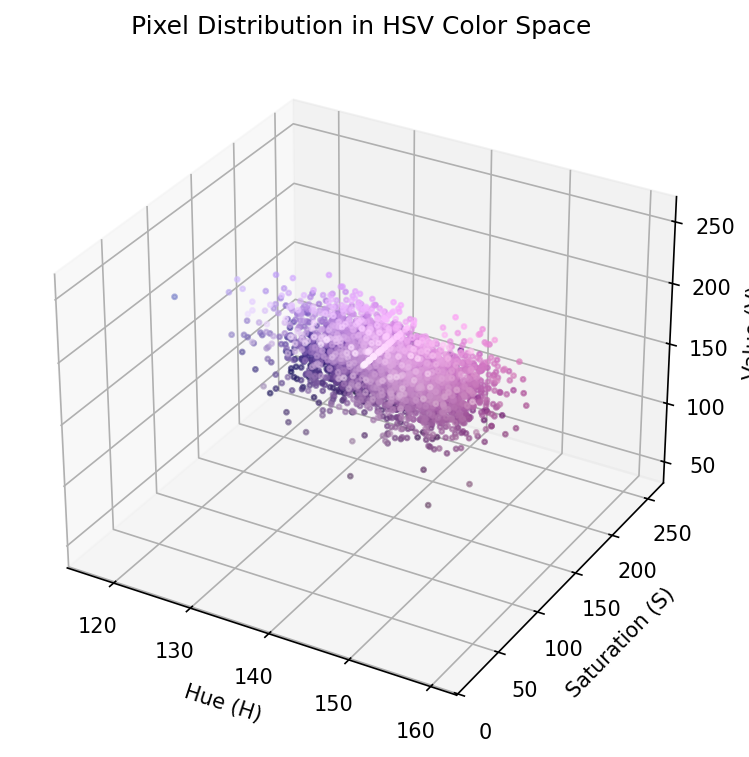

In [3]:
# Convert to HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Subsample pixels for a cleaner, faster plot (takes every 2nd pixel)
h = img_hsv[:, :, 0].flatten()[::2]
s = img_hsv[:, :, 1].flatten()[::2]
v = img_hsv[:, :, 2].flatten()[::2]

# Map original colors to the scatter points for visual clarity
colors = img_rgb.reshape(-1, 3)[::2] / 255.0

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(h, s, v, c=colors, marker='.', alpha=0.6)

ax.set_xlabel('Hue (H)')
ax.set_ylabel('Saturation (S)')
ax.set_zlabel('Value (V)')
ax.set_title('Pixel Distribution in HSV Color Space')

plt.savefig('hsv_scatter.png')
plt.show()

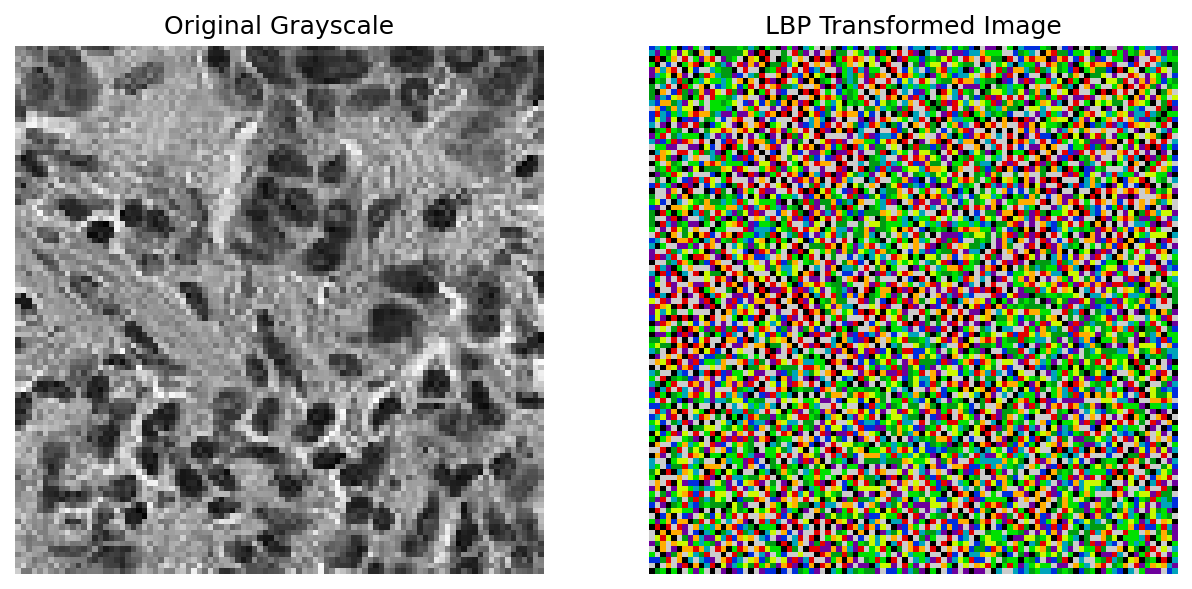

In [4]:
radius = 1
n_points = 8 * radius

# Compute uniform LBP
lbp_img = local_binary_pattern(img_gray, n_points, radius, method='uniform')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

# Plot LBP image
axes[1].imshow(lbp_img, cmap='nipy_spectral') # Spectral colormap highlights distinct patterns
axes[1].set_title('LBP Transformed Image')
axes[1].axis('off')

plt.savefig('lbp_transformation.png')
plt.show()

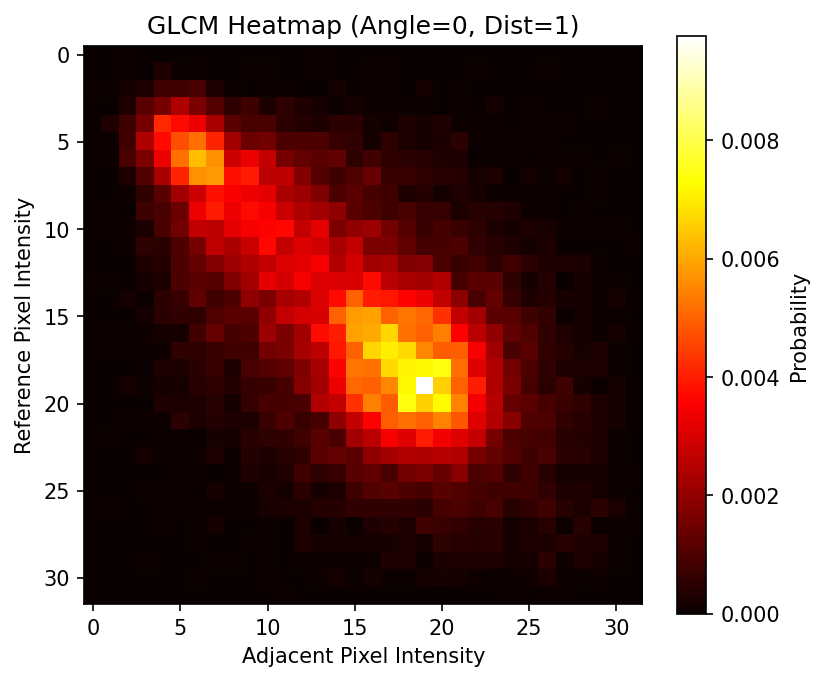

In [5]:
# Compute GLCM (Note: quantizing the image to 32 levels for a cleaner heatmap visualization)
quantized_img = (img_gray / 8).astype(np.uint8) 
glcm = graycomatrix(quantized_img, distances=[1], angles=[0], levels=32, symmetric=True, normed=True)

# Extract the 2D matrix for distance=1, angle=0
glcm_matrix = glcm[:, :, 0, 0]

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(glcm_matrix, cmap='hot', interpolation='nearest')
fig.colorbar(cax, label='Probability')

ax.set_title('GLCM Heatmap (Angle=0, Dist=1)')
ax.set_xlabel('Adjacent Pixel Intensity')
ax.set_ylabel('Reference Pixel Intensity')

plt.savefig('glcm_heatmap.png')
plt.show()

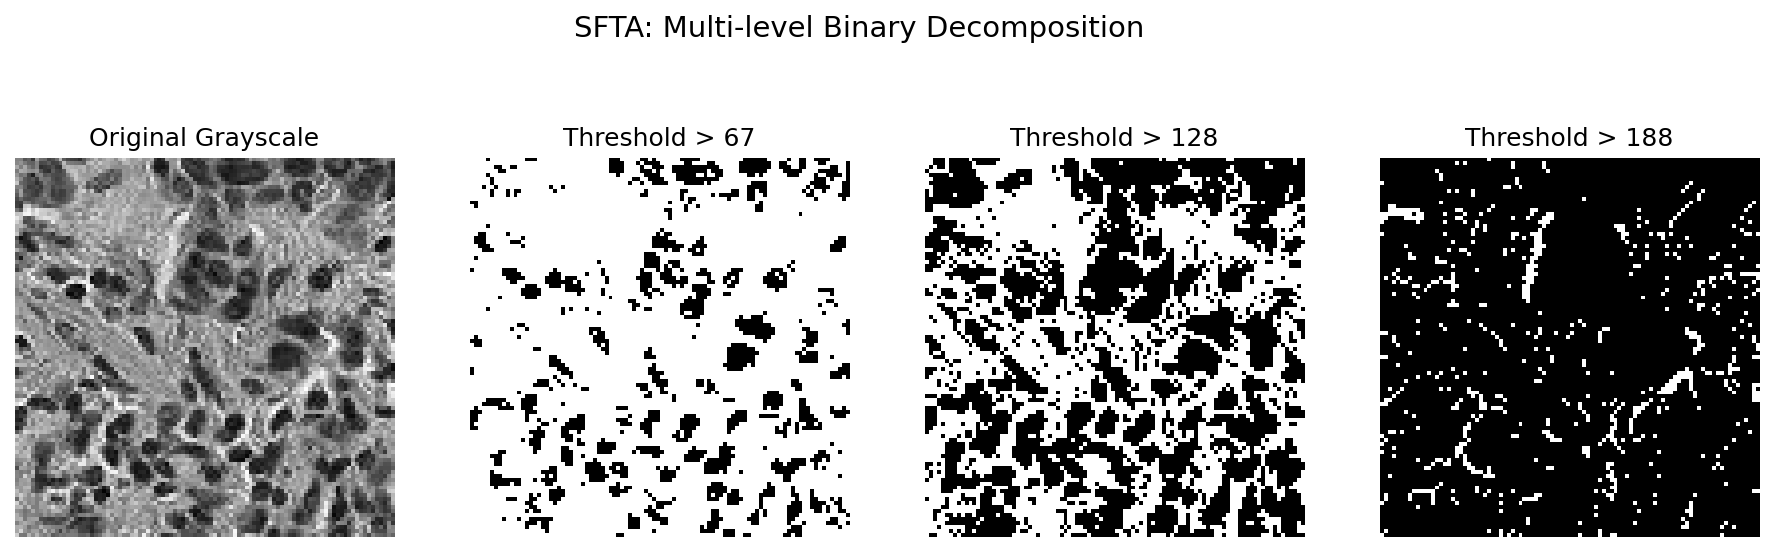

In [6]:
n_levels = 3
thresholds = np.linspace(img_gray.min(), img_gray.max(), n_levels + 2)[1:-1]

fig, axes = plt.subplots(1, n_levels + 1, figsize=(15, 4))

# Show original
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

# Show each thresholded binary layer
for i, t in enumerate(thresholds):
    binary = (img_gray > t).astype(np.uint8)
    axes[i+1].imshow(binary, cmap='binary_r')
    axes[i+1].set_title(f'Threshold > {t:.0f}')
    axes[i+1].axis('off')

plt.suptitle('SFTA: Multi-level Binary Decomposition', fontsize=14, y=1.05)
plt.savefig('sfta_decomposition.png')
plt.show()